<a href="https://colab.research.google.com/github/SattamAltwaim/EVE/blob/main/benchmarks/benchmark_text_lm_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVE Optimizer Benchmark: Text Generation on LM & LSTM

**EVE (ρ=0.58, K=4)** vs **SGD**, **AdamW**, **RMSProp** on WikiText-2 (language modeling).

### Focus
- **Time to converge** (wall-clock seconds to target perplexity)
- **Optimizer metrics**: steps/sec, time per epoch
- **Results**: best validation perplexity, final loss

### Architectures
- Small Transformer LM (decoder-only)
- LSTM language model

### Fast Colab run
Uses subset of WikiText-2 (~5k sequences), 20 epochs. ~5–10 min on A100.

In [1]:
# ── 0. Setup ─────────────────────────────────────────────────────────────
# Colab: clone repo + pip install datasets. Local: pip install -e . datasets
import os, sys, subprocess
if os.path.exists("/content"):
    subprocess.run(["git", "clone", "https://github.com/SattamAltwaim/EVE.git", "/content/EVE"],
                   capture_output=True, check=False)
    if "/content/EVE" not in sys.path:
        sys.path.insert(0, "/content/EVE")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "datasets"], check=False)
else:
    parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if os.path.exists(os.path.join(parent, "eve_optimizer")) and parent not in sys.path:
        sys.path.insert(0, parent)

from eve_optimizer import EVE
print("EVE imported successfully")

EVE imported successfully


In [2]:
# ── 1. Imports & Config ──────────────────────────────────────────────────
import math
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from eve_optimizer import EVE

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

EVE_RHO, EVE_K = 0.58, 4
EPOCHS = 20
BATCH_SIZE = 12
SEQ_LEN = 64
VOCAB_SIZE = 4000
SUBSET_SIZE = 5000

Device: cuda


In [3]:
# ── 2. WikiText-2 data loading ───────────────────────────────────────────
def load_wikitext2(subset_size=5000, seq_len=64, vocab_size=4000):
    from datasets import load_dataset
    ds = load_dataset("wikitext", "wikitext-2-raw-v1")
    train_texts = [t for t in ds["train"]["text"] if len(t.strip()) > 0][:subset_size]
    val_texts = [t for t in ds["validation"]["text"] if len(t.strip()) > 0][:500]

    tokenizer = lambda s: s.lower().split()
    all_tokens = []
    for t in train_texts:
        all_tokens.extend(tokenizer(t))
    vocab_counts = Counter(all_tokens)
    vocab = {"<pad>": 0, "<unk>": 1}
    for w, _ in vocab_counts.most_common(vocab_size - 2):
        vocab[w] = len(vocab)

    def encode(texts):
        out = []
        for t in texts:
            ids = [vocab.get(w, 1) for w in tokenizer(t)]
            for i in range(0, len(ids) - seq_len, seq_len // 2):
                chunk = ids[i:i + seq_len + 1]
                if len(chunk) == seq_len + 1:
                    out.append(chunk)
        return out

    train_ids = encode(train_texts)
    val_ids = encode(val_texts)
    return train_ids, val_ids, len(vocab)

class LMDataset(Dataset):
    def __init__(self, sequences):
        self.data = [torch.tensor(s, dtype=torch.long) for s in sequences]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, i):
        x = self.data[i][:-1]
        y = self.data[i][1:]
        return x, y

def collate_fn(batch):
    xs = torch.nn.utils.rnn.pad_sequence([b[0] for b in batch], batch_first=True, padding_value=0)
    ys = torch.nn.utils.rnn.pad_sequence([b[1] for b in batch], batch_first=True, padding_value=-100)
    return xs, ys

train_ids, val_ids, vocab_size = load_wikitext2(SUBSET_SIZE, SEQ_LEN, VOCAB_SIZE)
train_ds = LMDataset(train_ids)
val_ds = LMDataset(val_ids)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
print(f"Vocab size: {vocab_size}, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Vocab size: 4000, Train batches: 671, Val batches: 55


In [4]:
# ── 3. LM & LSTM models ──────────────────────────────────────────────────
def lm_loss_fn(logits, targets):
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1), ignore_index=-100)

class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=3, max_len=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)
    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        h = self.embed(x) + self.pos(pos)
        h = self.encoder(h)
        return self.head(h)

class LSTMLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.lstm = nn.LSTM(d_model, d_model, num_layers=num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(d_model, vocab_size)
    def forward(self, x):
        h = self.embed(x)
        h, _ = self.lstm(h)
        return self.head(h)

In [5]:
# ── 4. Optimizer factory & training ──────────────────────────────────────
@dataclass
class EpochMetrics:
    train_loss: float
    val_ppl: float
    epoch_time: float
    steps_per_sec: float
    epoch: int

def make_optimizer(name: str, model: nn.Module, lr: float = 1e-3, wd: float = 0.01):
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    elif name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "RMSProp":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "EVE":
        return EVE(model.parameters(), lr=lr, weight_decay=wd, K=EVE_K, rho=EVE_RHO)
    raise ValueError(name)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += lm_loss_fn(logits, y).item() * (y != -100).sum().item()
        n += (y != -100).sum().item()
    return math.exp(total_loss / n) if n > 0 else float("inf")

def train_one_epoch(model, loader, optimizer, device, opt_name, max_grad_norm=1.0):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = lm_loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        if opt_name == "EVE":
            optimizer.step(model=model, loss_fn=lm_loss_fn, data=(x, y))
        else:
            optimizer.step()
        total_loss += loss.item() * (y != -100).sum().item()
        n += (y != -100).sum().item()
    return total_loss / n if n > 0 else 0.0

In [6]:
# ── 5. Benchmark runner ─────────────────────────────────────────────────
ARCHS = ["TransformerLM", "LSTMLM"]
OPTS = ["SGD", "AdamW", "RMSProp", "EVE"]
LR_MAP = {"SGD": 0.1, "AdamW": 1e-3, "RMSProp": 1e-3, "EVE": 1e-3}
TARGET_PPL = 50.0  # target perplexity (lower is better)

def make_model(arch: str):
    if arch == "TransformerLM":
        return TransformerLM(vocab_size, d_model=128, nhead=4, num_layers=3, max_len=SEQ_LEN + 1)
    elif arch == "LSTMLM":
        return LSTMLM(vocab_size, d_model=128, num_layers=2)
    raise ValueError(arch)

def run_benchmark(seed=42):
    results = defaultdict(dict)
    for arch in ARCHS:
        print(f"\n{'='*60}\n  {arch}\n{'='*60}")
        for opt_name in OPTS:
            torch.manual_seed(seed)
            model = make_model(arch).to(DEVICE)
            optimizer = make_optimizer(opt_name, model, LR_MAP[opt_name])

            history = []
            cum_time = 0.0
            time_to_target = None
            for ep in range(1, EPOCHS + 1):
                t0 = time.perf_counter()
                tr_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, opt_name)
                elapsed = time.perf_counter() - t0
                cum_time += elapsed
                val_ppl = evaluate(model, val_loader, DEVICE)
                sps = len(train_loader) / elapsed if elapsed > 0 else 0
                history.append(EpochMetrics(tr_loss, val_ppl, elapsed, sps, ep))
                if time_to_target is None and val_ppl <= TARGET_PPL:
                    time_to_target = cum_time
                if ep % 5 == 0 or ep == 1:
                    print(f"  {opt_name:8} ep={ep:2d} loss={tr_loss:.4f} val_ppl={val_ppl:.2f} {elapsed:.1f}s")

            results[arch][opt_name] = {
                "history": history,
                "time_to_target": time_to_target,
                "best_val_ppl": min(h.val_ppl for h in history),
                "total_time": cum_time,
            }
            del model, optimizer
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
    return results

In [7]:
# ── 6. Run benchmark ─────────────────────────────────────────────────────
results = run_benchmark()


  TransformerLM
  SGD      ep= 1 loss=5.6563 val_ppl=189.40 6.6s
  SGD      ep= 5 loss=5.5999 val_ppl=210.86 5.9s
  SGD      ep=10 loss=5.6059 val_ppl=236.66 5.8s
  SGD      ep=15 loss=5.6208 val_ppl=238.76 5.8s
  SGD      ep=20 loss=5.6164 val_ppl=221.36 5.8s
  AdamW    ep= 1 loss=2.8971 val_ppl=1.47 6.1s
  AdamW    ep= 5 loss=0.0922 val_ppl=1.09 6.0s
  AdamW    ep=10 loss=0.0616 val_ppl=1.11 6.2s
  AdamW    ep=15 loss=0.0331 val_ppl=1.14 6.0s
  AdamW    ep=20 loss=0.0240 val_ppl=1.15 6.1s
  RMSProp  ep= 1 loss=5.6450 val_ppl=207.80 6.1s
  RMSProp  ep= 5 loss=5.4612 val_ppl=182.49 6.1s
  RMSProp  ep=10 loss=5.3841 val_ppl=174.25 6.0s
  RMSProp  ep=15 loss=5.3866 val_ppl=175.41 6.0s
  RMSProp  ep=20 loss=5.3887 val_ppl=175.23 6.1s


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:921: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_transformer_encoder_layer_fwd. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:80.)
  return torch._transformer_encoder_layer_fwd(


  EVE      ep= 1 loss=3.2100 val_ppl=2.32 27.4s
  EVE      ep= 5 loss=0.0965 val_ppl=1.09 27.3s
  EVE      ep=10 loss=0.0619 val_ppl=1.10 27.4s
  EVE      ep=15 loss=0.0299 val_ppl=1.12 27.2s
  EVE      ep=20 loss=0.0196 val_ppl=1.15 27.1s

  LSTMLM
  SGD      ep= 1 loss=5.9709 val_ppl=273.81 2.3s
  SGD      ep= 5 loss=5.8537 val_ppl=275.72 2.2s
  SGD      ep=10 loss=5.8551 val_ppl=276.29 2.1s
  SGD      ep=15 loss=5.8584 val_ppl=274.08 2.2s
  SGD      ep=20 loss=5.8565 val_ppl=277.33 2.2s
  AdamW    ep= 1 loss=5.7261 val_ppl=181.32 2.3s
  AdamW    ep= 5 loss=4.8516 val_ppl=111.77 2.3s
  AdamW    ep=10 loss=4.4234 val_ppl=92.51 2.3s
  AdamW    ep=15 loss=4.1129 val_ppl=89.51 2.3s
  AdamW    ep=20 loss=3.8646 val_ppl=91.10 2.3s
  RMSProp  ep= 1 loss=5.8615 val_ppl=273.57 2.2s
  RMSProp  ep= 5 loss=5.8495 val_ppl=272.03 2.3s
  RMSProp  ep=10 loss=5.8491 val_ppl=274.89 2.2s
  RMSProp  ep=15 loss=5.8486 val_ppl=276.26 2.2s
  RMSProp  ep=20 loss=5.8490 val_ppl=274.38 2.2s
  EVE      ep= 1 l

In [8]:
# ── 7. Optimizer metrics & results ───────────────────────────────────────
print("=" * 80)
print("  OPTIMIZER METRICS — Time to Converge & Efficiency")
print("=" * 80)
for arch in ARCHS:
    print(f"\n{arch} (target val_ppl <= {TARGET_PPL})")
    print("-" * 60)
    print(f"{'Optimizer':<10} {'Time to target (s)':<20} {'Best val_ppl':<14} {'Total time (s)':<14}")
    for opt in OPTS:
        r = results[arch][opt]
        tt = f"{r['time_to_target']:.2f}" if r["time_to_target"] else "N/A"
        print(f"{opt:<10} {tt:<20} {r['best_val_ppl']:.2f}          {r['total_time']:.2f}")

  OPTIMIZER METRICS — Time to Converge & Efficiency

TransformerLM (target val_ppl <= 50.0)
------------------------------------------------------------
Optimizer  Time to target (s)   Best val_ppl   Total time (s)
SGD        N/A                  189.40          117.39
AdamW      6.07                 1.09          121.58
RMSProp    N/A                  173.71          120.96
EVE        27.42                1.09          544.68

LSTMLM (target val_ppl <= 50.0)
------------------------------------------------------------
Optimizer  Time to target (s)   Best val_ppl   Total time (s)
SGD        N/A                  271.16          43.32
AdamW      N/A                  88.77          45.80
RMSProp    N/A                  267.90          44.74
EVE        N/A                  87.98          230.90


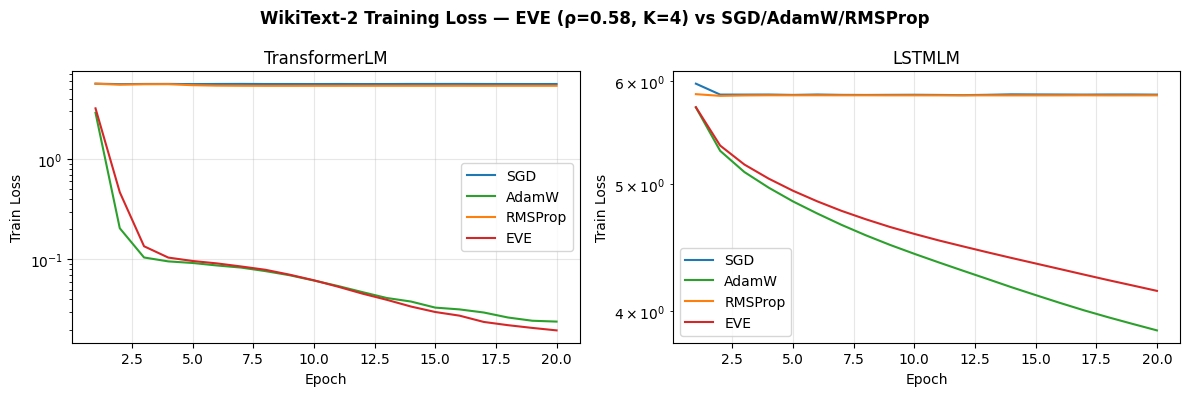

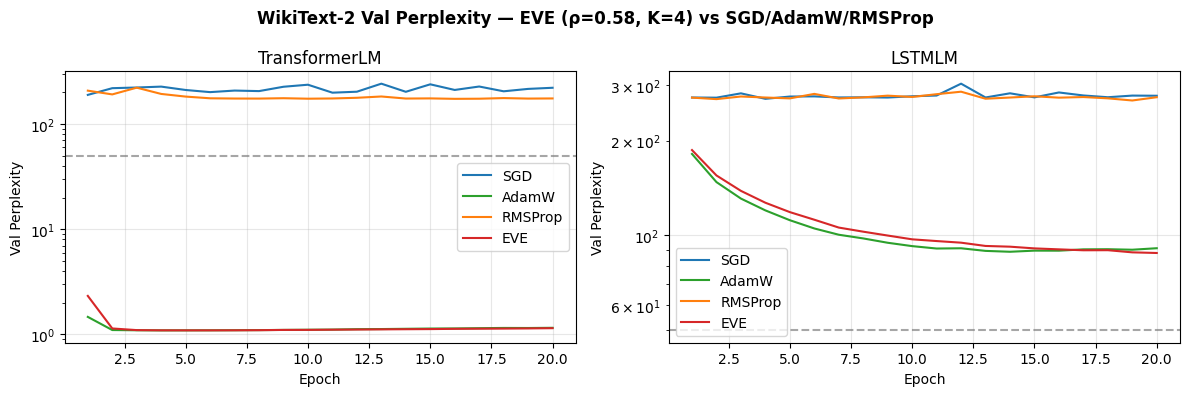

In [9]:
# ── 8. Plots ─────────────────────────────────────────────────────────────
colors = {"SGD": "#1f77b4", "AdamW": "#2ca02c", "RMSProp": "#ff7f0e", "EVE": "#d62728"}

# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ARCHS):
    for opt in OPTS:
        hist = results[arch][opt]["history"]
        ax.plot([h.epoch for h in hist], [h.train_loss for h in hist], label=opt, color=colors[opt])
    ax.set_title(arch)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("WikiText-2 Training Loss — EVE (ρ=0.58, K=4) vs SGD/AdamW/RMSProp", fontweight="bold")
plt.tight_layout()
plt.show()

# Validation perplexity curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ARCHS):
    for opt in OPTS:
        hist = results[arch][opt]["history"]
        ax.plot([h.epoch for h in hist], [h.val_ppl for h in hist], label=opt, color=colors[opt])
    ax.axhline(TARGET_PPL, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(arch)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Perplexity")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("WikiText-2 Val Perplexity — EVE (ρ=0.58, K=4) vs SGD/AdamW/RMSProp", fontweight="bold")
plt.tight_layout()
plt.show()